## Info of the dataset
- MedInc: Median income in the block.
- HouseAge: Median age of houses in the block.
- AveRooms: Average number of rooms per dwelling.
- AveBedrms: Average number of bedrooms per dwelling.
- Population: Block population.
- AveOccup: Average dwelling occupancy.
- Latitude: Block latitude.
- Longitude: Block longitude.


In [13]:
import numpy as np
import pandas as pd
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import Lasso, LassoCV 
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline
import seaborn as sns # for data visualization
from sklearn.model_selection import KFold, GridSearchCV
from sklearn.pipeline import Pipeline  

In [ ]:
# Load the dataset
california_housing = fetch_california_housing(as_frame=True)
df_cal = california_housing.frame 
X, y = california_housing.data, california_housing.target

df_cal.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   MedInc       20640 non-null  float64
 1   HouseAge     20640 non-null  float64
 2   AveRooms     20640 non-null  float64
 3   AveBedrms    20640 non-null  float64
 4   Population   20640 non-null  float64
 5   AveOccup     20640 non-null  float64
 6   Latitude     20640 non-null  float64
 7   Longitude    20640 non-null  float64
 8   MedHouseVal  20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB


In [ ]:
display(df_cal)


columna = []
media = []
max_vals = []
min_vals = []


for columna in df_cal.columns:
    media.append(df_cal[columna].mean())
    max_vals.append(df_cal[columna].max())
    min_vals.append(df_cal[columna].min())

estadisticas = pd.DataFrame({'Columna': df_cal.columns, 'Media': media, 'Maximum': max_vals, 'Minimum': min_vals})
estadisticas

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422
...,...,...,...,...,...,...,...,...,...
20635,1.5603,25.0,5.045455,1.133333,845.0,2.560606,39.48,-121.09,0.781
20636,2.5568,18.0,6.114035,1.315789,356.0,3.122807,39.49,-121.21,0.771
20637,1.7000,17.0,5.205543,1.120092,1007.0,2.325635,39.43,-121.22,0.923
20638,1.8672,18.0,5.329513,1.171920,741.0,2.123209,39.43,-121.32,0.847


,Columna,Media,Maximum,Minimum
0,MedInc,3.870671,15.000100,0.499900
1,HouseAge,28.639486,52.000000,1.000000
2,AveRooms,5.429000,141.909091,0.846154
3,AveBedrms,1.096675,34.066667,0.333333
4,Population,1425.476744,35682.000000,3.000000
5,AveOccup,3.070655,1243.333333,0.692308
6,Latitude,35.631861,41.950000,32.540000
7,Longitude,-119.569704,-114.310000,-124.350000
8,MedHouseVal,2.068558,5.000010,0.149990


## Contents of next block code

- Preparation: Split the dataset into Training (80%) and Testing (20%) sets. He then standardized the data so all features were on a level playing field.

- The "Bad" Example: Generated 100 alphas and trained 100 models using the unscaled data. He plotted it to show you that Lasso fails and behaves erratically if you don't standardize.

- The "Good" Example: Repeated the process with the standardized data. He plotted it to show you a clean, mathematical progression where features smoothly drop to zero based on their actual importance.

- The Human Choice: Looked at that good graph and manually decided, "Ah, Alpha 0.1 looks like a great spot where the noise is eliminated but the strong signals remain."

- Training the Final Model: Built one final, official model using alpha=0.1 and trained it on the scaled data.

- Testing & Evaluation: He gave the final model an exam using the 20% hidden test data, printed its numerical scores (MSE) and (R^2), and created two final graphs to easily show the class which features survived and how accurate the predictions were.

c:\Users\ibane\anaconda3\envs\AnalysisD\lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 4.924e+03, tolerance: 9.296e+00
  model = cd_fast.enet_coordinate_descent(
c:\Users\ibane\anaconda3\envs\AnalysisD\lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 4.921e+03, tolerance: 9.296e+00
  model = cd_fast.enet_coordinate_descent(
c:\Users\ibane\anaconda3\envs\AnalysisD\lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing reg

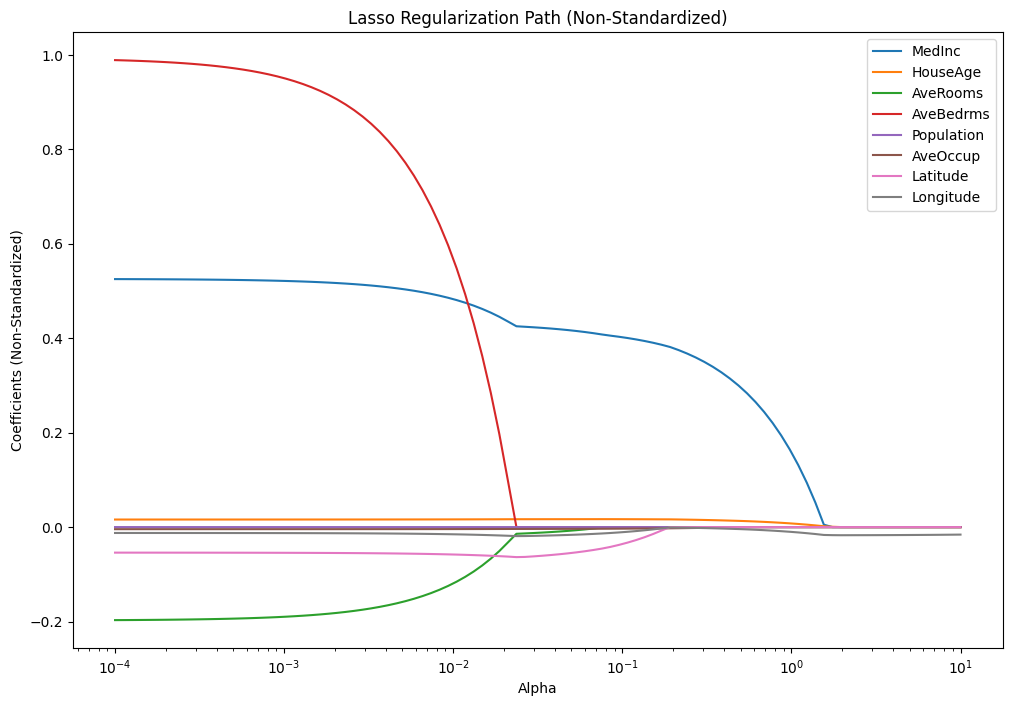

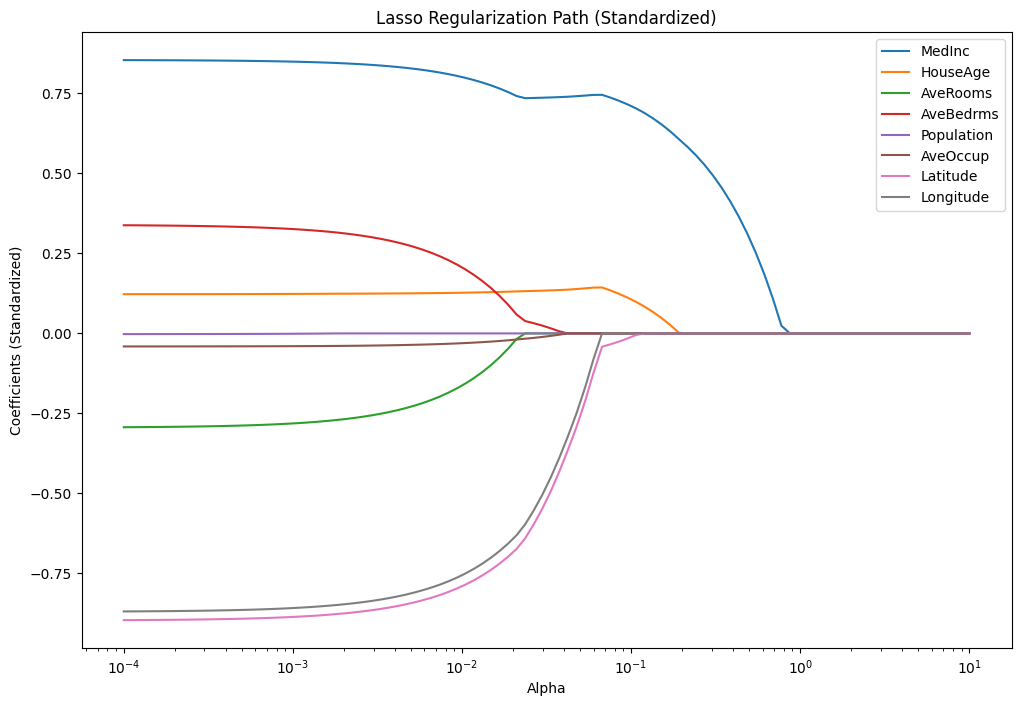

Mean Squared Error (MSE, standardized): 0.68
R-squared (R2, standardized): 0.48


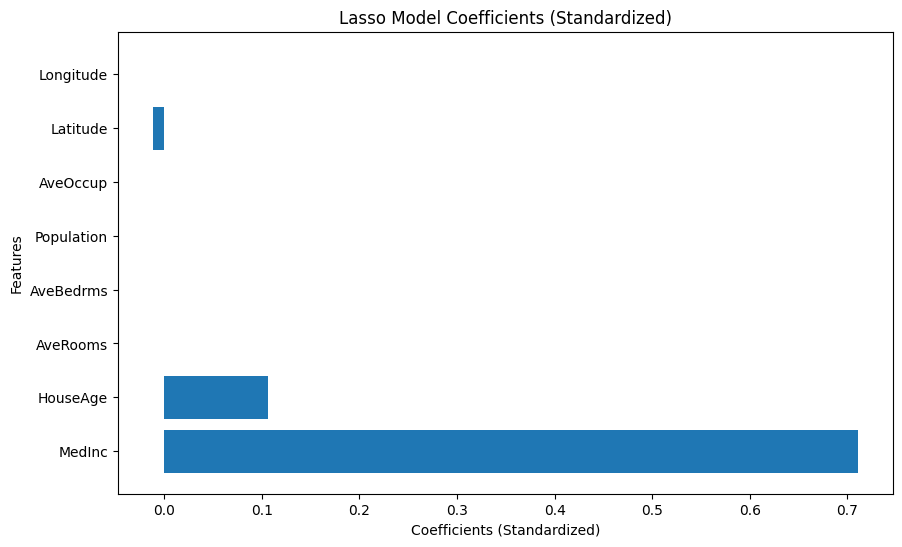

TypeError: 'list' object is not callable

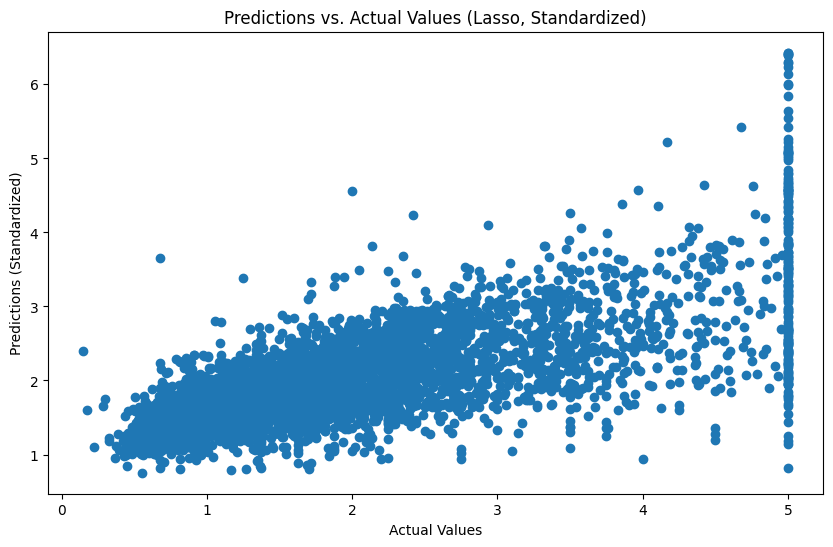

In [ ]:
# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Standardize the data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Generate the regularization path (non-standardized)
alphas = np.logspace(-4, 1, 100) #We generate the alphas with a logarithmic space (100 alphas between 10^-4 and 10^1)
coefs = []

"""
Why do we use logspace?

Lasso es extremadamente sensible a cambios pequeños cuando α es muy bajo. La diferencia entre
α=0.0001 y α=0.001 puede ser abismal (puede que se eliminen 10 variables en ese pequeño tramo). 
Sin embargo, la diferencia entre α=8 y α=9 suele ser irrelevante, 
porque para entonces probablemente ya casi todos los coeficientes son cero.

La escala logarítmica nos permite "hacer zoom" en los valores pequeños y ser más generales en los valores grandes.

The teacher trained 100 lasso models for 100 alphas for al features in 100 instances that are plotted dot by dot forming a line.
"""

#Loop that for each alpha it trains the model and appends to the coef list the lasso coeficiente obtained for each feature
for a in alphas:
    lasso = Lasso(alpha=a, fit_intercept=False)
    lasso.fit(X_train, y_train)
    coefs.append(lasso.coef_)

# Plot the regularization path (non-standardized)
plt.figure(figsize=(12, 8))
for i in range(X_train.shape[1]):
    plt.plot(alphas, [coef[i] for coef in coefs], label=X_train.columns[i])
plt.xscale('log')
plt.xlabel('Alpha')
plt.ylabel('Coefficients (Non-Standardized)')
plt.title('Lasso Regularization Path (Non-Standardized)')
plt.legend(loc='upper right')
plt.axis('tight')
plt.show()

"""
WE REPEAT THE PROCESS BUT FOR STANDARDIZED
"""


# Generate the regularization path (standardized)
alphas = np.logspace(-4, 1, 100)
coefs_scaled = []

for a in alphas:
    lasso_scaled = Lasso(alpha=a, fit_intercept=False)
    lasso_scaled.fit(X_train_scaled, y_train)
    coefs_scaled.append(lasso_scaled.coef_)

# Plot the regularization path (standardized)
plt.figure(figsize=(12, 8))
for i in range(X_train_scaled.shape[1]):
    plt.plot(alphas, [coef[i] for coef in coefs_scaled], label=X_train.columns[i])
plt.xscale('log')
plt.xlabel('Alpha')
plt.ylabel('Coefficients (Standardized)')
plt.title('Lasso Regularization Path (Standardized)')
plt.legend(loc='upper right')
plt.axis('tight')
plt.show()




# Create and train the Lasso model (with a specific alpha and standardized data)
alpha = 0.1
lasso_scaled = Lasso(alpha=alpha)
lasso_scaled.fit(X_train_scaled, y_train)

# Make predictions on the test set (standardized)
y_pred_scaled = lasso_scaled.predict(X_test_scaled)

# Evaluate the model performance (standardized)
mse_scaled = mean_squared_error(y_test, y_pred_scaled)
r2_scaled = r2_score(y_test, y_pred_scaled)

print(f"Mean Squared Error (MSE, standardized): {mse_scaled:.2f}")
print(f"R-squared (R2, standardized): {r2_scaled:.2f}")

# Visualize the model coefficients (standardized)
coefficients_scaled = lasso_scaled.coef_
feature_names = X.columns

plt.figure(figsize=(10, 6))
plt.barh(feature_names, coefficients_scaled)
plt.xlabel("Coefficients (Standardized)")
plt.ylabel("Features")
plt.title("Lasso Model Coefficients (Standardized)")
plt.show()

# Visualize predictions vs. actual values (standardized)
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred_scaled)
plt.xlabel("Actual Values")
plt.ylabel("Predictions (Standardized)")
plt.title("Predictions vs. Actual Values (Lasso, Standardized)")
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], color='red')
plt.show()

# Cross validation to obtain the best alpha

In [ ]:
# Build the Pipeline (Standardization + LassoCV)
# cv=5 means 5-fold cross-validation
# n_alphas=100 means it will test 100 different alpha values automatically
lasso_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('lasso', LassoCV(cv=5, n_alphas=100, random_state=42, max_iter=10000))
])

lasso_pipeline.fit(X_train, y_train)

# Extract the optimized Alpha and evaluate the model
# Access the lasso model from inside the pipeline using .named_steps
best_lasso_model = lasso_pipeline.named_steps['lasso']
optimal_alpha = best_lasso_model.alpha_ # .alpha_ selects the best alpha obtained during training

print(f"Optimal Alpha found via Cross-Validation: {optimal_alpha:.4f}")

# Test the model on the unseen test data
y_pred = lasso_pipeline.predict(X_test)
print(f" Model R^2 Score on Test Data: {r2_score(y_test, y_pred):.4f}")
print(f" Model RMSE on Test Data: {np.sqrt(mean_squared_error(y_test, y_pred)):.4f}\n")

# We use .coef_ to select the most relevant features
# Extract the coefficients and pair them with feature names
coefficients = best_lasso_model.coef_
feature_names = X.columns

# Create a DataFrame to view the features easily
feature_importance = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': coefficients,
    'Absolute_Importance': np.abs(coefficients) # Absolute value determines overall impact
})

# Sort by importance (highest to lowest)
feature_importance = feature_importance.sort_values(by='Absolute_Importance', ascending=False)

print("Feature Relevance (Most to Least Important):")
display(feature_importance[['Feature', 'Coefficient']])

c:\Users\ibane\anaconda3\envs\AnalysisD\lib\site-packages\sklearn\linear_model\_coordinate_descent.py:1622: FutureWarning: 'n_alphas' was deprecated in 1.7 and will be removed in 1.9. 'alphas' now accepts an integer value which removes the need to pass 'n_alphas'. The default value of 'alphas' will change from None to 100 in 1.9. Pass an explicit value to 'alphas' and leave 'n_alphas' to its default value to silence this warning.
  warnings.warn(


Optimal Alpha found via Cross-Validation: 0.0008
 Model R^2 Score on Test Data: 0.5766
 Model RMSE on Test Data: 0.7448

Feature Relevance (Most to Least Important):


,Feature,Coefficient
6,Latitude,-0.888039
7,Longitude,-0.860441
0,MedInc,0.850206
3,AveBedrms,0.328723
2,AveRooms,-0.283936
1,HouseAge,0.123187
5,AveOccup,-0.040079
4,Population,-0.001312
